In [8]:
import os
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

#### confiurações

In [9]:
BASE_DIR = Path(
    r"C:\Users\vitor\Documents\GitHub\Cap-1---Visao-Computacional-na-Clinica\dataset\dataset_rebalanced"
)

IMG_SIZE = (224, 224)

#### verificação das classes

In [10]:
classes = ["NORMAL", "PNEUMONIA"]

for split in ["train", "val", "test"]:

    print(f"\n{split.upper()}")

    for classe in classes:

        total = len(
            list(
                (BASE_DIR / split / classe).glob("*")
            )
        )

        print(f"{classe}: {total}")


TRAIN
NORMAL: 1108
PNEUMONIA: 2991

VAL
NORMAL: 237
PNEUMONIA: 641

TEST
NORMAL: 238
PNEUMONIA: 641


#### função de préprocessamento

In [11]:
def preprocess_image(image_path):

    img = cv2.imread(str(image_path))

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    img = cv2.resize(
        img,
        IMG_SIZE
    )

    img = img.astype(np.float32) / 255.0

    return img

### visualização do resultado

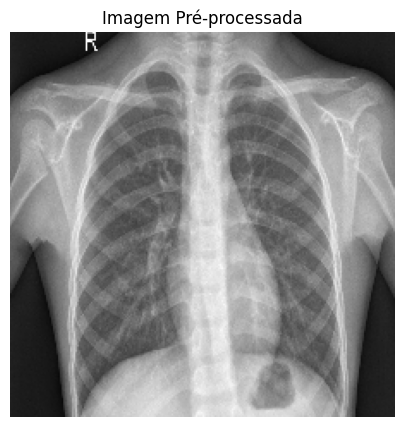

In [12]:
sample_image = next(
    (BASE_DIR / "train" / "NORMAL").glob("*")
)

img = preprocess_image(sample_image)

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.title("Imagem Pré-processada")
plt.show()

#### estatísticas do dataset

In [13]:
heights = []
widths = []

for split in ["train", "val", "test"]:

    for classe in classes:

        pasta = BASE_DIR / split / classe

        for arquivo in pasta.glob("*"):

            img = cv2.imread(str(arquivo))

            if img is None:
                continue

            h, w = img.shape[:2]

            heights.append(h)
            widths.append(w)

In [14]:
print("Altura média:", np.mean(heights))
print("Largura média:", np.mean(widths))

print("Menor altura:", np.min(heights))
print("Maior altura:", np.max(heights))

print("Menor largura:", np.min(widths))
print("Maior largura:", np.max(widths))

Altura média: 970.6890368852459
Largura média: 1327.880806010929
Menor altura: 127
Maior altura: 2713
Menor largura: 384
Maior largura: 2916


#### verificação de imagens corrompidas

In [15]:
corrompidas = []

for split in ["train", "val", "test"]:

    for classe in classes:

        pasta = BASE_DIR / split / classe

        for arquivo in pasta.glob("*"):

            img = cv2.imread(str(arquivo))

            if img is None:
                corrompidas.append(str(arquivo))

print(
    f"Imagens corrompidas: {len(corrompidas)}"
)

Imagens corrompidas: 0
